In [582]:
##importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import ttest_ind



Text(0, 0.5, 'y')

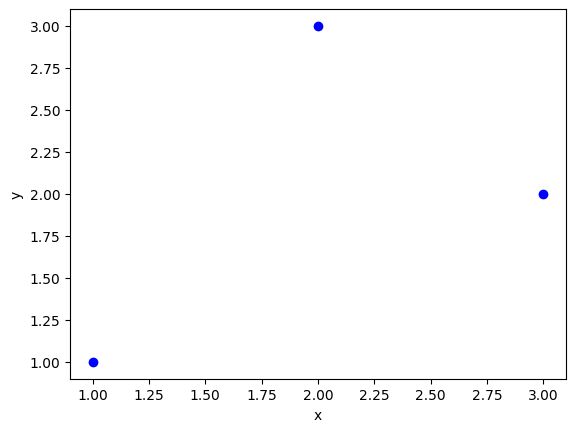

In [583]:
# hard coding values

y = [1,2,3]
x = [1,3,2]


#plotting the values

plt.scatter(x,y,color = 'blue')
plt.xlabel('x')
plt.ylabel('y')

In [584]:
# Note: It needs our x values to be a 2D array for the x-values, otherwise it will flag an error

x_shaped = np.array(x).reshape(-1, 1)
# Fitting the simple linnear model
model = LinearRegression()
model.fit(x_shaped, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


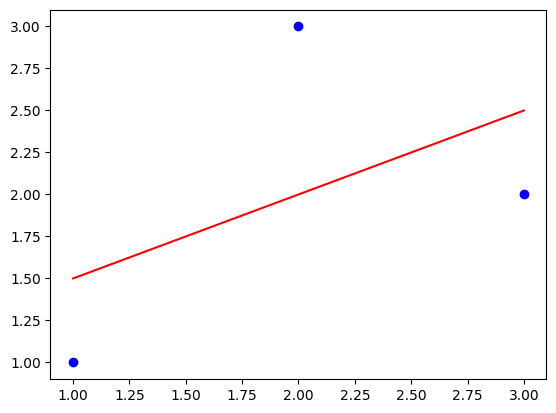

In [585]:
# Getting the coefficients
intercept = model.intercept_
slope = model.coef_[0]


# Plot data and fitted line

plt.scatter(x, y, color='blue', label='Data')
x_line = np.linspace(min(x), max(x), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', label=f'Fit: Y = {intercept:.2f} + {slope:.2f}X')

In [586]:
# we need the output table, and scikit learn won't produce the output table so we need to use statsmdoels
# first we need to add the contant values to the x values
X_sm = sm.add_constant(x_shaped)  # adds the intercept column w/the 1 values which is needed to calculate the y-intercpet correctly which impacts the slope
model_sm = sm.OLS(y, X_sm).fit()

print (intercept)
print(slope)
model_sm.summary().tables[1]


1.0000000000000004
0.4999999999999998


/Users/dustinh/Desktop/harvard_chan/bst_220/hw/hw_1/.venv-3.10/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


,coef,std err,t,P>|t|,[0.025,0.975]
const,1.0000,1.871,0.535,0.687,-22.771,24.771
x1,0.5000,0.866,0.577,0.667,-10.504,11.504


In [587]:
# Now lets work on HW 1 Continued 
# First lets import the data

hw_1_continued_data = pd.read_csv("/Users/dustinh/Downloads/SCCS2_v12.csv")
hw_1_continued_data

,Unnamed: 0,caseID,ethnic,height,weight,waist,hip,tc,tg,hdl,...,diabetes,hypertension,educ,drink,smoke,gender,alcohol,age,ihd,Dummy2
0,1,23,1,177.350006,58.000000,69.500000,92.00,4.65,0.54,1.07,...,0,1,3.0,1,1,0,2,35.972622,0,2
1,2,39,1,173.350006,64.099998,75.550003,95.50,6.26,1.20,1.20,...,0,1,2.0,1,1,0,2,31.663244,0,0
2,3,42,1,177.100006,52.200001,63.000000,89.00,4.81,0.79,1.64,...,0,1,5.0,0,1,0,1,29.963039,0,2
3,4,51,1,167.800003,59.700001,72.000000,92.75,5.06,2.19,1.13,...,0,1,5.0,1,1,0,2,30.696783,0,0
4,5,68,1,172.300003,65.699997,72.500000,99.00,4.85,1.35,1.15,...,0,1,3.0,1,1,0,2,27.978098,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,523,4413,3,155.100006,64.699997,84.500000,98.50,6.29,1.71,0.75,...,1,1,NaN,0,0,1,1,47.485283,0,0
523,524,4422,3,158.199997,65.500000,83.500000,102.00,4.79,2.15,0.87,...,1,1,2.0,0,0,1,1,37.177277,0,2
524,525,4432,3,162.600006,63.400002,81.500000,101.50,5.10,0.63,1.35,...,1,2,NaN,0,0,1,1,53.078712,0,2
525,526,4433,3,152.399994,68.000000,87.500000,109.00,7.50,3.27,0.64,...,1,1,NaN,0,0,1,1,65.388092,1,0


In [588]:
#now lets assign x and y variables


X = hw_1_continued_data[["age"]]

y = hw_1_continued_data["tc"]

print(type(X))
print(X.shape)
print(type(y))
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
(527, 1)
<class 'pandas.core.series.Series'>
(527,)


In [589]:
#As a reminder now that we have our variables defined, we need to flatten our x values to use stats models
#The reason why we need to flatten our x, is because statsmodels requires this to produce a parameter table
x_shaped = np.array(X/10).reshape(-1, 1)
#NOTE: I added the (X/10) part above because we need to fit the model on a decade change per the instructions
X_sm = sm.add_constant(x_shaped)  # adds the intercept column w/the 1 values which is needed to calculate the y-intercpet correctly which impacts the slope
model_sm_pt_2 = sm.OLS(y, X_sm).fit()


In [590]:
# Getting the Table
model_sm_pt_2.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,4.3762,0.136,32.214,0.000,4.109,4.643
x1,0.2624,0.030,8.849,0.000,0.204,0.321


In [591]:
# ok now we are going to calculate the pearson correlation
# note, this is very annnoying, but statsmodels required x to be a 2D but flattened array when fitting a linnear model, but to find the pearson correlation, both x and y need to be 1D
age_1d = hw_1_continued_data["age"]
chol_1d = hw_1_continued_data["tc"]

r, p_value = pearsonr(age_1d, chol_1d)
print(r)


0.36027299887253195


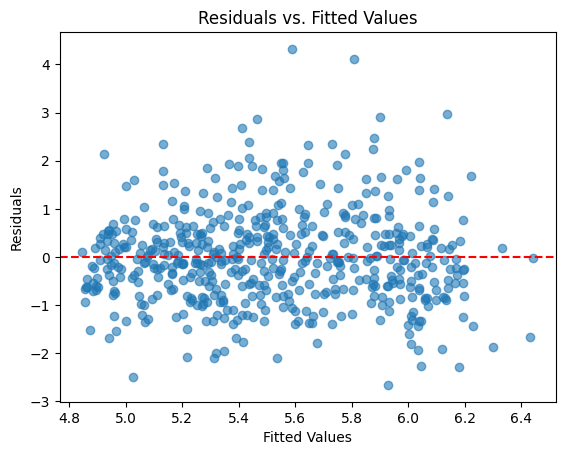

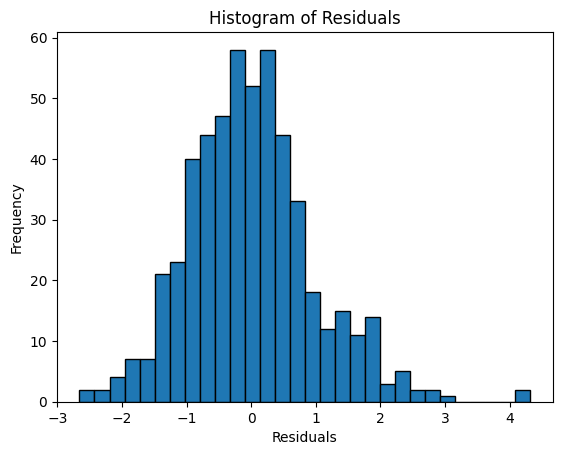

In [592]:
# notw lets graph the residuals
fitted_vals = model_sm_pt_2.fittedvalues
residuals = model_sm_pt_2.resid

plt.scatter(fitted_vals, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')  # reference line at 0
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

# now lets plot the histogram

plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.savefig("histogram_residuals.png", dpi=300, bbox_inches='tight')
plt.show()


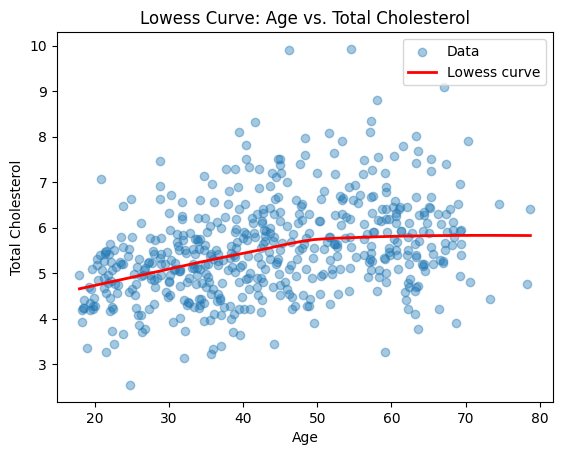

In [593]:
#ok now we are moving on to a lowess smoothing curve

# age_1d and chol_1d are the 1D variables
smoothed = lowess(chol_1d, age_1d)

plt.scatter(age_1d, chol_1d, alpha=0.4, label="Data")
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2, label="Lowess curve")
plt.xlabel("Age")
plt.ylabel("Total Cholesterol")
plt.title("Lowess Curve: Age vs. Total Cholesterol")
plt.legend()
plt.savefig("lowess_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [594]:
#now the assignment is having us add a new 2 degree polynomial to the fuction
#The concept should be that if it is just a normal regression, the x squared coefficient should come out close to zero

# Create the quadratic term
age_sq = age_1d ** 2

# Stack age and age^2 as two columns for statsmodels
X_quad = np.column_stack((age_1d, age_sq))
X_quad_sm = sm.add_constant(X_quad)

model_quad = sm.OLS(chol_1d, X_quad_sm).fit()
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     46.41
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.78e-19
Time:                        15:48:36   Log-Likelihood:                -729.86
No. Observations:                 527   AIC:                             1466.
Df Residuals:                     524   BIC:                             1479.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0658      0.391      7.847      0.0

In [595]:
#moving on to questoin two. We have to run a varience t-test 

# Split cholesterol by sex group
male_chol = hw_1_continued_data[hw_1_continued_data["gender"] == 0]["tc"]
female_chol = hw_1_continued_data[hw_1_continued_data["gender"] == 1]["tc"]

t_stat, p_value = ttest_ind(male_chol, female_chol, equal_var=True)
print(t_stat, p_value)


#retroactivly adding this for
n1 = len(male_chol)
n2 = len(female_chol)
df_ttest = n1 + n2 - 2
print(n1, n2, df_ttest)

-0.6387380452616115 0.5232719074028458
288 239 525


In [596]:
#now we have to fit a simple linnear regression on those values
gender_1d = hw_1_continued_data["gender"]

#remember to shape our value
gender_shaped = np.array(gender_1d).reshape(-1, 1)
#we have to add the constant too
X_gender_sm = sm.add_constant(gender_shaped)

model_gender = sm.OLS(chol_1d, X_gender_sm).fit()
print(model_gender.summary())



                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4080
Date:                Thu, 17 Sep 2026   Prob (F-statistic):              0.523
Time:                        15:48:36   Log-Likelihood:                -772.63
No. Observations:                 527   AIC:                             1549.
Df Residuals:                     525   BIC:                             1558.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4908      0.062     88.722      0.0

In [597]:
#now we are adding another predictor - gender - to our multiple linnear regression model
#note, I didn't mention this with the 2 degree polynomial regression, but we need to use column stack command now. It takes multipe 1D arrays and turns them into a 2D array


# Build the design matrix: age, age^2, and gender together
X_full = np.column_stack((age_1d, age_1d**2, gender_1d))
X_full_sm = sm.add_constant(X_full)

model_full = sm.OLS(chol_1d, X_full_sm).fit()
print(model_full.summary())


#the next question is asking for crude vs. adjusted rates so we need less ronding
print(model_sm.params)   
print(model_full.params)  
print(model_quad.params)

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     31.36
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.18e-18
Time:                        15:48:36   Log-Likelihood:                -729.24
No. Observations:                 527   AIC:                             1466.
Df Residuals:                     523   BIC:                             1484.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0390      0.391      7.765      0.0

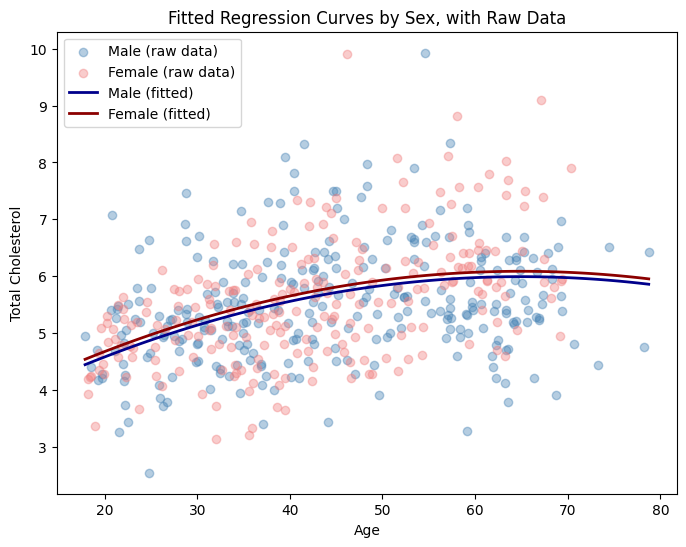

In [598]:
# Create a smooth range of ages spanning your data
age_range = np.linspace(age_1d.min(), age_1d.max(), 100)

# Fitted equations for each sex
male_fitted = 3.0390 + 0.0909*age_range - 0.0007*age_range**2
female_fitted = 3.1335 + 0.0909*age_range - 0.0007*age_range**2

# Scatter plot of raw data, colored by sex
plt.figure(figsize=(8, 6))
plt.scatter(hw_1_continued_data[hw_1_continued_data["gender"] == 0]["age"],
            hw_1_continued_data[hw_1_continued_data["gender"] == 0]["tc"],
            alpha=0.4, label="Male (raw data)", color="steelblue")
plt.scatter(hw_1_continued_data[hw_1_continued_data["gender"] == 1]["age"],
            hw_1_continued_data[hw_1_continued_data["gender"] == 1]["tc"],
            alpha=0.4, label="Female (raw data)", color="lightcoral")

# Overlay fitted curves
plt.plot(age_range, male_fitted, color="darkblue", linewidth=2, label="Male (fitted)")
plt.plot(age_range, female_fitted, color="darkred", linewidth=2, label="Female (fitted)")

plt.xlabel("Age")
plt.ylabel("Total Cholesterol")
plt.title("Fitted Regression Curves by Sex, with Raw Data")
plt.legend()
plt.savefig("fitted_by_sex.png", dpi=300, bbox_inches='tight')
plt.show()

In [599]:
#now for D3, we need to build out an interaction model

# Create interaction terms
age_sex_interaction = age_1d * gender_1d
age_sq_sex_interaction = (age_1d**2) * gender_1d

# Build the design matrix
X_interaction = np.column_stack((age_1d, age_1d**2, gender_1d, age_sex_interaction, age_sq_sex_interaction))
X_interaction_sm = sm.add_constant(X_interaction)

model_interaction = sm.OLS(chol_1d, X_interaction_sm).fit()
print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     23.43
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.93e-21
Time:                        15:48:36   Log-Likelihood:                -719.39
No. Observations:                 527   AIC:                             1451.
Df Residuals:                     521   BIC:                             1476.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7876      0.526      5.300      0.0

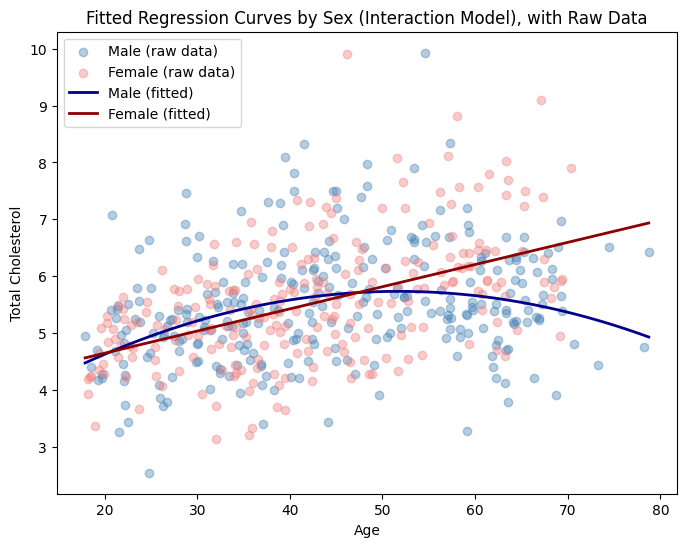

In [600]:
#now lets plot the values

# Smooth age range (reuse the same range as before)
age_range = np.linspace(age_1d.min(), age_1d.max(), 100)

# Fitted equations from the interaction model
male_fitted_interaction = 2.7876 + 0.1138*age_range - 0.0011*age_range**2
female_fitted_interaction = 3.8630 + 0.0390*age_range + 0.0000*age_range**2

# Scatter plot of raw data, colored by sex
plt.figure(figsize=(8, 6))
plt.scatter(hw_1_continued_data[hw_1_continued_data["gender"] == 0]["age"],
            hw_1_continued_data[hw_1_continued_data["gender"] == 0]["tc"],
            alpha=0.4, label="Male (raw data)", color="steelblue")
plt.scatter(hw_1_continued_data[hw_1_continued_data["gender"] == 1]["age"],
            hw_1_continued_data[hw_1_continued_data["gender"] == 1]["tc"],
            alpha=0.4, label="Female (raw data)", color="lightcoral")

# Overlay fitted curves
plt.plot(age_range, male_fitted_interaction, color="darkblue", linewidth=2, label="Male (fitted)")
plt.plot(age_range, female_fitted_interaction, color="darkred", linewidth=2, label="Female (fitted)")

plt.xlabel("Age")
plt.ylabel("Total Cholesterol")
plt.title("Fitted Regression Curves by Sex (Interaction Model), with Raw Data")
plt.legend()
plt.savefig("fitted_interaction_by_sex.png", dpi=300, bbox_inches='tight')
plt.show()

In [601]:
#for question E, we need to know MSE values. Good news is that is is actually pretty easy since we already built the models. We just need to run one command to get the values


print(np.sqrt(model_sm.mse_resid))           # Model 1: age only
print(np.sqrt(model_quad.mse_resid))         # Model 2: age + age^2
print(np.sqrt(model_gender.mse_resid))       # Model 3: sex only
print(np.sqrt(model_full.mse_resid))         # Model 4: age + age^2 + sex
print(np.sqrt(model_interaction.mse_resid))  # Model 5: full interaction model

#thne do the same for the r squared values

print(model_sm.rsquared, model_sm.rsquared_adj)
print(model_quad.rsquared, model_quad.rsquared_adj)
print(model_gender.rsquared, model_gender.rsquared_adj)
print(model_full.rsquared, model_full.rsquared_adj)
print(model_interaction.rsquared, model_interaction.rsquared_adj)

1.2247448713915887
0.9693257066579135
1.0502678695363223
0.9691128763323968
0.9529995927786478
0.25000000000000033 -0.49999999999999933
0.15047939111362563 0.14723694604154025
0.0007765133022532567 -0.0011267695295518187
0.15247291140247743 0.14761137934551272
0.18355614504478424 0.1757207913503963


In [602]:
#I overwrote my model 1 so just adding back for the problem
x_shaped = np.array(X).reshape(-1, 1)
X_sm = sm.add_constant(x_shaped)
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.nobs)
print(model_sm.rsquared, model_sm.rsquared_adj)

527.0
0.12979663371660766 0.12813910349511548


In [603]:
# now for question F, we are splitting the two graphs apart 


# Split the dataset by sex
male_data = hw_1_continued_data[hw_1_continued_data["gender"] == 0]
female_data = hw_1_continued_data[hw_1_continued_data["gender"] == 1]

# Male model: age + age^2 only, fit on male data only
male_age = male_data["age"]
male_chol_full = male_data["tc"]
X_male = np.column_stack((male_age, male_age**2))
X_male_sm = sm.add_constant(X_male)
model_male_only = sm.OLS(male_chol_full, X_male_sm).fit()

# Female model: age + age^2 only, fit on female data only
female_age = female_data["age"]
female_chol_full = female_data["tc"]
X_female = np.column_stack((female_age, female_age**2))
X_female_sm = sm.add_constant(X_female)
model_female_only = sm.OLS(female_chol_full, X_female_sm).fit()
print(model_female_only.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     41.63
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.27e-16
Time:                        15:48:36   Log-Likelihood:                -323.85
No. Observations:                 239   AIC:                             653.7
Df Residuals:                     236   BIC:                             664.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8630      0.567      6.815      0.0

In [604]:
print(model_male_only.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     17.20
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           8.86e-08
Time:                        15:48:36   Log-Likelihood:                -395.50
No. Observations:                 288   AIC:                             797.0
Df Residuals:                     285   BIC:                             808.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7876      0.530      5.259      0.0

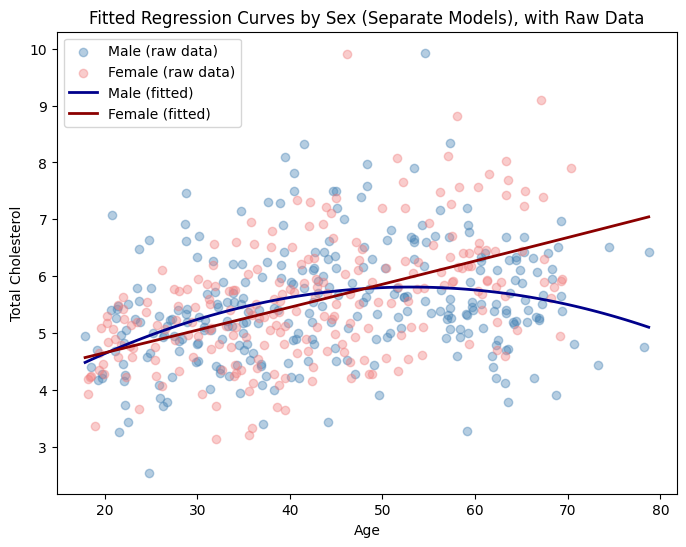

In [605]:
# now lets plot our separate equations

# Pull coefficients directly from the fitted models
male_b0, male_b1, male_b2 = model_male_only.params
female_b0, female_b1, female_b2 = model_female_only.params

# Smooth age range
age_range = np.linspace(age_1d.min(), age_1d.max(), 100)

# Fitted equations from the SEPARATE models (Part F)
male_fitted_separate = male_b0 + male_b1*age_range + male_b2*age_range**2
female_fitted_separate = female_b0 + female_b1*age_range + female_b2*age_range**2

# Scatter plot of raw data, colored by sex
plt.figure(figsize=(8, 6))
plt.scatter(male_data["age"], male_data["tc"],
alpha=0.4, label="Male (raw data)", color="steelblue")
plt.scatter(female_data["age"], female_data["tc"],
alpha=0.4, label="Female (raw data)", color="lightcoral")

# Overlay fitted curves
plt.plot(age_range, male_fitted_separate, color="darkblue", linewidth=2, label="Male (fitted)")
plt.plot(age_range, female_fitted_separate, color="darkred", linewidth=2, label="Female (fitted)")

plt.xlabel("Age")
plt.ylabel("Total Cholesterol")
plt.title("Fitted Regression Curves by Sex (Separate Models), with Raw Data")
plt.legend()
plt.savefig("fitted_separate_by_sex.png", dpi=300, bbox_inches='tight')
plt.show()

In [606]:
#now we move onto our final question which invovles calculating BMI

# first we need meters, then BMI
height_meters = hw_1_continued_data["height"] / 100
hw_1_continued_data["bmi"] = hw_1_continued_data["weight"] / (height_meters ** 2)

print(hw_1_continued_data["bmi"].describe())


#now that we have our new bmi column, we can create the bins

bins = [-float('inf'), 18.5, 25.0, 30.0, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

hw_1_continued_data['bmi_category'] = pd.cut(hw_1_continued_data['bmi'], bins=bins, labels=labels, right=False)

print(hw_1_continued_data['bmi_category'].value_counts())

count    527.000000
mean      24.161284
std        4.363799
min       15.165667
25%       21.280483
50%       23.886561
75%       26.542911
max       40.493672
Name: bmi, dtype: float64
bmi_category
Normal         273
Overweight     157
Underweight     50
Obese           47
Name: count, dtype: int64


In [607]:
#now its time to make our first model. We are going to use continous i.e no bins

bmi_1d = hw_1_continued_data["bmi"]

bmi_shaped = np.array(bmi_1d).reshape(-1, 1)
X_bmi_sm = sm.add_constant(bmi_shaped)

model_bmi_continuous = sm.OLS(chol_1d, X_bmi_sm).fit()
print(model_bmi_continuous.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     32.70
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.80e-08
Time:                        15:48:36   Log-Likelihood:                -756.91
No. Observations:                 527   AIC:                             1518.
Df Residuals:                     525   BIC:                             1526.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1100      0.250     16.435      0.0

In [608]:
#now we are going to do continous i.e bins

# need Create dummy variables. This is becasue you cant do math on words
bmi_dummies = pd.get_dummies(hw_1_continued_data["bmi_category"], drop_first=False)
bmi_dummies = bmi_dummies.drop(columns=["Normal"]) 


X_bmi_cat = sm.add_constant(bmi_dummies.astype(float))
model_bmi_categorical = sm.OLS(chol_1d, X_bmi_cat).fit()
print(model_bmi_categorical.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     9.590
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.57e-06
Time:                        15:48:36   Log-Likelihood:                -758.72
No. Observations:                 527   AIC:                             1525.
Df Residuals:                     523   BIC:                             1543.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           5.4502      0.062     87.867      

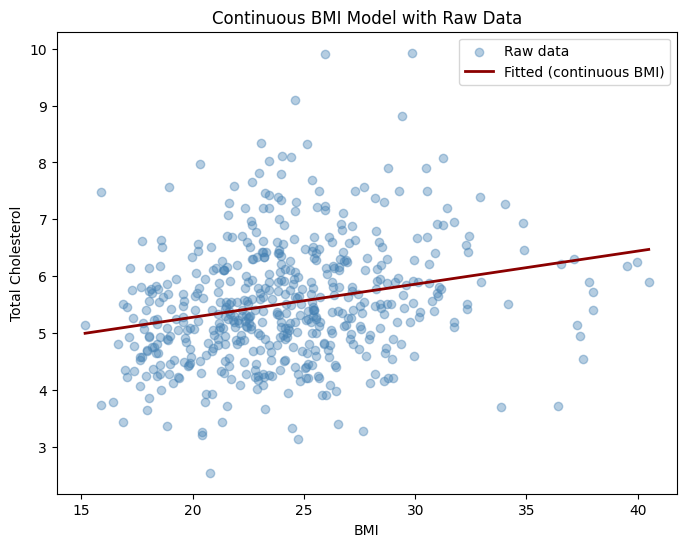

In [609]:
#now we have to make scatter plots/regressions for the continues BMI and the categorical BMI
#first we will start with the continues regression. Standard regression here. 

b0, b1 = model_bmi_continuous.params

bmi_range = np.linspace(bmi_1d.min(), bmi_1d.max(), 100)
continuous_fitted = b0 + b1*bmi_range

plt.figure(figsize=(8, 6))
plt.scatter(bmi_1d, chol_1d, alpha=0.4, color="steelblue", label="Raw data")
plt.plot(bmi_range, continuous_fitted, color="darkred", linewidth=2, label="Fitted (continuous BMI)")
plt.xlabel("BMI")
plt.ylabel("Total Cholesterol")
plt.title("Continuous BMI Model with Raw Data")
plt.legend()
plt.savefig("bmi_continuous_fit.png", dpi=300, bbox_inches='tight')
plt.show()

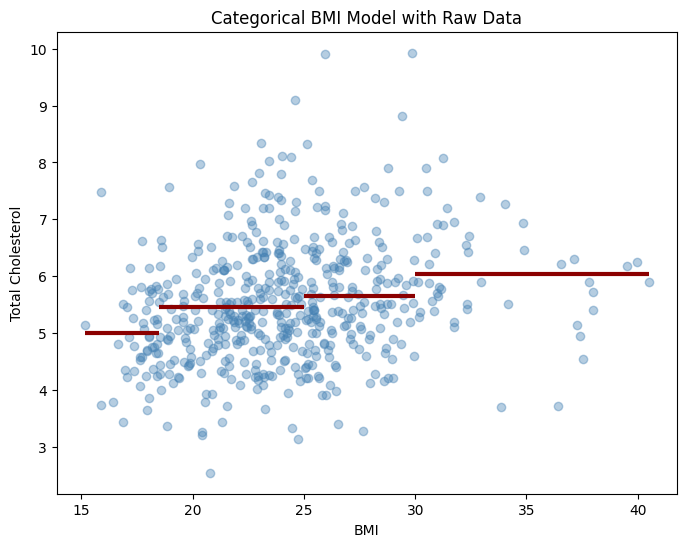

In [610]:
#now lets do the categorical one

params = model_bmi_categorical.params

fitted_values = {
    "Underweight": params["const"] + params["Underweight"],
    "Normal": params["const"],
    "Overweight": params["const"] + params["Overweight"],
    "Obese": params["const"] + params["Obese"]
}

bounds = {
    "Underweight": (bmi_1d.min(), 18.5),
    "Normal": (18.5, 25.0),
    "Overweight": (25.0, 30.0),
    "Obese": (30.0, bmi_1d.max())
}

plt.figure(figsize=(8, 6))
plt.scatter(bmi_1d, chol_1d, alpha=0.4, color="steelblue", label="Raw data")

for category, (low, high) in bounds.items():
    plt.hlines(fitted_values[category], low, high, color="darkred", linewidth=3)

plt.xlabel("BMI")
plt.ylabel("Total Cholesterol")
plt.title("Categorical BMI Model with Raw Data")
plt.savefig("bmi_categorical_fit.png", dpi=300, bbox_inches='tight')
plt.show()

In [611]:
bmi_sq = bmi_1d ** 2
X_bmi_quad = np.column_stack((bmi_1d, bmi_sq))
X_bmi_quad_sm = sm.add_constant(X_bmi_quad)

model_bmi_quad = sm.OLS(chol_1d, X_bmi_quad_sm).fit()
print(model_bmi_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     19.86
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           4.86e-09
Time:                        15:48:36   Log-Likelihood:                -753.58
No. Observations:                 527   AIC:                             1513.
Df Residuals:                     524   BIC:                             1526.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6192      0.997      1.625      0.1

In [612]:
#now we are taking the best two models and turning them into a single "super" multi-linnear regression model

# Build the full combined design matrix
X_combined = np.column_stack((
    age_1d,                          # x1: age - original age column 
    age_1d**2,                       #  x2: age^2 - here is the double polynomial age
    gender_1d,                       # x3: sex - same deal here w sex
    age_1d * gender_1d,              # x4: age x sex the multiplcation between the two
    (age_1d**2) * gender_1d,         # x5: age^2 x sex 
    bmi_1d,                          # x6: BMI
    bmi_1d**2                        # x7: BMI^2
))
X_combined_sm = sm.add_constant(X_combined)

model_combined = sm.OLS(chol_1d, X_combined_sm).fit()
print(model_combined.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     18.58
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           3.89e-22
Time:                        15:48:36   Log-Likelihood:                -713.90
No. Observations:                 527   AIC:                             1444.
Df Residuals:                     519   BIC:                             1478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5237      1.045      0.501      0.6

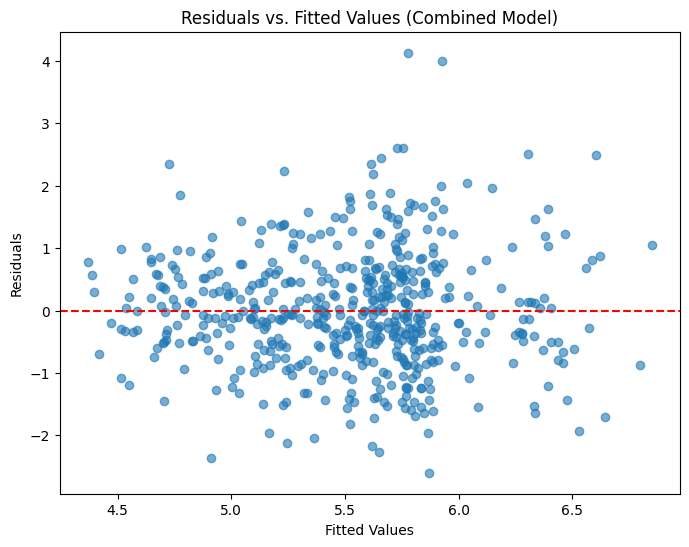

In [613]:
#lets build the scatter plot to determine residuals vs. fitted vlaues

fitted_vals_combined = model_combined.fittedvalues
residuals_combined = model_combined.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted_vals_combined, residuals_combined, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values (Combined Model)")
plt.savefig("residuals_combined.png", dpi=300, bbox_inches='tight')
plt.show()

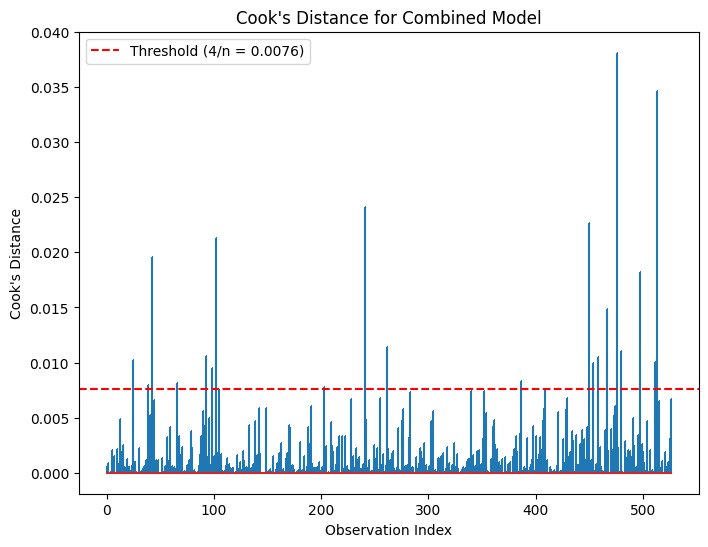

Number of high-influence points: 20
Indices: [ 24  38  42  65  92  98 102 203 241 261 386 450 454 458 467 476 480 497
 511 513]
Number of high-influence points: 20
Indices: [ 24  38  42  65  92  98 102 203 241 261 386 450 454 458 467 476 480 497
 511 513]

Top 10 highest Cook's Distance observations:
Index 476: Cook's D = 0.0381
Index 513: Cook's D = 0.0346
Index 241: Cook's D = 0.0241
Index 450: Cook's D = 0.0226
Index 102: Cook's D = 0.0213
Index 42: Cook's D = 0.0195
Index 497: Cook's D = 0.0182
Index 467: Cook's D = 0.0149
Index 261: Cook's D = 0.0114
Index 480: Cook's D = 0.0110


In [614]:
#finally, we have to look at leverage and influence
#cooks method is used in class slides


influence = model_combined.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(8, 6))
plt.stem(cooks_d, markerfmt=",")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Combined Model")
plt.axhline(y=4/len(cooks_d), color='red', linestyle='--', label=f"Threshold (4/n = {4/len(cooks_d):.4f})")
plt.legend()
plt.savefig("cooks_distance.png", dpi=300, bbox_inches='tight')
plt.show()

# Identify which specific observations exceed the threshold
threshold = 4/len(cooks_d)
high_influence_indices = np.where(cooks_d > threshold)[0]
print(f"Number of high-influence points: {len(high_influence_indices)}")
print(f"Indices: {high_influence_indices}")

threshold = 4/len(cooks_d)
high_influence_indices = np.where(cooks_d > threshold)[0]
print(f"Number of high-influence points: {len(high_influence_indices)}")
print(f"Indices: {high_influence_indices}")

# Show the top 10 highest Cook's Distance values specifically
top_10 = np.argsort(cooks_d)[-10:][::-1]
print("\nTop 10 highest Cook's Distance observations:")
for idx in top_10:
    print(f"Index {idx}: Cook's D = {cooks_d[idx]:.4f}")

In [615]:
#it does appear that actully more than 10 seem to have high leverage so lets take them out

# Take the 10 most influential observations
top_10_indices = np.argsort(cooks_d)[-10:]

# Drop these from your data
hw_1_dropped = hw_1_continued_data.drop(index=hw_1_continued_data.index[top_10_indices])

# Rebuild your predictors from the dropped dataset
age_dropped = hw_1_dropped["age"]
gender_dropped = hw_1_dropped["gender"]
bmi_dropped = hw_1_dropped["bmi"]
chol_dropped = hw_1_dropped["tc"]

X_combined_dropped = np.column_stack((
    age_dropped,
    age_dropped**2,
    gender_dropped,
    age_dropped * gender_dropped,
    (age_dropped**2) * gender_dropped,
    bmi_dropped,
    bmi_dropped**2
))
X_combined_dropped_sm = sm.add_constant(X_combined_dropped)

model_combined_dropped = sm.OLS(chol_dropped, X_combined_dropped_sm).fit()
print(model_combined_dropped.summary())


leverage = influence.hat_matrix_diag

# Common rule of thumb for high leverage: > 2*(p+1)/n, where p = number of predictors
p = 7  # number of predictors in your combined model
n = len(leverage)
leverage_threshold = 2*(p+1)/n

print(f"Leverage threshold: {leverage_threshold:.4f}")

# Check leverage specifically for your 10 flagged high-influence points
for idx in top_10_indices:
    print(f"Index {idx}: Leverage = {leverage[idx]:.4f}, Cook's D = {cooks_d[idx]:.4f}, Residual = {residuals_combined[idx]:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     20.58
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           2.16e-24
Time:                        15:48:37   Log-Likelihood:                -668.21
No. Observations:                 517   AIC:                             1352.
Df Residuals:                     509   BIC:                             1386.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5599      1.009      0.555      0.5